정상 0
불량 1
불량 2
불량 3


---
# 1.1 필요 라이브러리 및 폰트 로드

In [41]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from IPython.display import display
import warnings
import platform

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)


print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)


라이브러리 로드 완료!
한글 폰트 설정 완료!


In [42]:
from scipy.stats import shapiro
from scipy import stats
from scipy.stats import levene


# 1.2 데이터 로드

In [43]:
# 1. 원본 데이터 로드
df_original_2 = pd.read_csv("for_통계_overall_data_product-2.csv")


# 3. 첫 번째 컬럼을 기준으로 분리된 데이터 프레임 생성
df_process_2 = pd.read_csv("for_통계_process_data_product-2.csv")
df_sensor_2 = pd.read_csv("for_통계_sensor_data_product-2.csv")
df_defects_2 = pd.read_csv("for_통계_defects_data_product-2.csv")

In [44]:
print(df_original_2.shape)
print(df_process_2.shape)
print(df_sensor_2.shape)
print(df_defects_2.shape)

(3328, 34)
(3328, 24)
(3328, 7)
(3328, 3)


In [45]:
df_original_2.head()

,shot_key,velocity_1,velocity_2,velocity_3,high_velocity,cylinder_pressure,rapid_rise_time,biscuit_thickness,clamping_force,cycle_time,pressure_rise_time,casting_pressure,spray_time,spray_1_time,spray_2_time,velocity_1_outlier_flag,velocity_3_outlier_flag,cylinder_pressure_outlier_flag,rapid_rise_time_outlier_flag,biscuit_thickness_outlier_flag,cycle_time_outlier_flag,casting_pressure_outlier_flag,spray_time_outlier_flag,spray_1_time_outlier_flag,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity,factory_temp_outlier_flag,surface_defect,structural_defect,contamination_defect
0,4207011_11,0.156,0.166,0.192,2.723,265,0.012,20,357,36.55,0.041,595.0,12.5,2.0,2.2,0,0,0,0,0,1,0,0,0,671.6,6.5,26.1,2.70,33.2,57.4,0,0,0,0
1,4208012_12,0.157,0.166,0.204,2.730,265,0.014,19,359,36.50,0.040,594.0,12.5,2.0,2.2,0,0,1,0,0,0,0,0,0,672.1,6.4,26.2,2.71,33.3,57.0,0,0,0,0
2,4209013_13,0.156,0.170,0.204,2.715,265,0.012,18,361,36.50,0.041,595.0,12.5,2.0,2.2,0,0,0,0,0,0,0,0,0,672.4,6.4,26.2,2.70,33.5,56.7,0,0,0,0
3,4210014_14,0.154,0.170,0.202,2.717,265,0.011,20,364,36.50,0.042,595.0,12.5,2.0,2.2,0,0,1,0,0,0,0,0,0,672.4,6.4,26.2,2.70,33.5,56.7,0,0,0,0
4,4211015_15,0.146,0.160,0.198,2.684,265,0.012,20,357,36.50,0.042,595.0,12.5,2.0,2.2,0,0,1,0,0,0,0,0,0,672.4,6.3,26.2,2.71,33.6,56.4,0,0,0,0


# 통계 계획 수립

## 타깃이 0/1 이진 변수
Welch t-test (정규성 어느 정도 + 등분산 불만족도 가능)\
    정규성, 등분산성 검증 필요

Mann-Whitney U test (비모수)

## 타깃이 3개 이상 범주형

0 = 양품 / 1 = 표면불량 / 2 = 구조불량 / 3 = 이물질불량

ANOVA\
Welch ANOVA\
Kruskal-Wallis\

윌콕슨 검정? : 보통 같은 대상의 전/후 비교, 혹은 짝지어진 두 집단 비교

만휘트니 U 검정: 독립인 두 집단 비교

크루스칼-왈리스 검정: 독립인 세 집단 이상 비교용 비모수 검정 (다중 클래스 타깃)

# 1단계 간단한 기술통계
평균, 중앙값, 표준편차\
최소/최대\
왜도\

In [46]:
# 1. Process, Sensor 관련 데이터의 기술통계 딸깍
def create_continuous_statistics_summary(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"{df_name} 연속형 변수 기술통계량")
    print(f"{'='*80}\n")
    
    # 1-1. exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 1-2. 기초 통계량
    stats_df = df_copied.describe().T
    stats_df['Skewness'] = df_copied.skew()
    
    # 1-3. 컬럼명 한글로 변경
    stats_df.rename(columns={
        'count': '개수',
        'mean': '평균',
        'std': '표준편차',
        'min': '최솟값',
        '25%': 'Q1의 경계값',
        '50%': '중앙값',
        '75%': 'Q3의 경계값',
        'max': '최댓값',
        'Skewness': '왜도'
    }, inplace=True)
    
    display(stats_df)

In [47]:
# 2. 0/1 이진 변수 요약 딸깍
def create_binary_summary(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"{df_name} 0/1 이진 변수 요약")
    print(f"{'='*80}\n")
    
    # 2-1. exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 2-2. 요약표 생성
    summary_df = pd.DataFrame(index=df_copied.columns)
    summary_df['개수'] = df_copied.count()
    summary_df['0의 개수'] = (df_copied == 0).sum()
    summary_df['1의 개수'] = (df_copied == 1).sum()
    summary_df['1의 비율(%)'] = (df_copied.mean() * 100).round(2)
    summary_df['0의 비율(%)'] = ((1 - df_copied.mean()) * 100).round(2)
    
    display(summary_df)

In [48]:
create_continuous_statistics_summary(df_process_2, "process", exclude_cols="product_type" )
create_continuous_statistics_summary(df_sensor_2, "sensor")
create_binary_summary(df_defects_2, "defects",)


process 연속형 변수 기술통계량



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,왜도
velocity_1,3328.0,0.154473,0.004836,0.139961,0.1515,0.156,0.158,0.162,-0.721449
velocity_2,3328.0,0.168620,0.004023,0.158000,0.1660,0.168,0.172,0.178,0.066497
velocity_3,3328.0,0.202256,0.004921,0.187391,0.2000,0.202,0.206,0.216,-0.162441
high_velocity,3328.0,2.553245,0.071882,2.470000,2.5140,2.524,2.538,2.744,1.57937
cylinder_pressure,3328.0,265.000000,0.000000,265.000000,265.0000,265.000,265.000,265.000,0.0
rapid_rise_time,3328.0,0.011660,0.000887,0.009000,0.0110,0.012,0.012,0.014,-0.645101
biscuit_thickness,3328.0,17.610276,1.370777,14.000000,17.0000,18.000,19.000,22.000,-0.135318
clamping_force,3328.0,370.342548,10.160827,346.000000,361.0000,375.000,379.000,388.000,-0.470378
cycle_time,3328.0,35.876908,0.300762,35.350000,35.8000,36.000,36.100,36.550,-0.623103
pressure_rise_time,3328.0,0.036638,0.002946,0.031000,0.0340,0.036,0.040,0.045,0.692732



sensor 연속형 변수 기술통계량



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,왜도
melting_furnace_temp,3328.0,655.703996,8.494439,635.300000,648.70,655.4,662.50,678.10,0.273951
air_pressure,3328.0,6.120583,0.677288,4.600000,5.60,6.2,6.80,7.10,-0.378966
coolant_temp,3328.0,26.923347,0.551408,25.900000,26.50,26.8,27.30,28.10,0.282971
coolant_pressure,3328.0,2.689742,0.056365,2.580000,2.63,2.7,2.74,2.79,-0.210328
factory_temp,3328.0,32.572087,1.521800,28.003531,31.60,32.0,32.50,37.00,1.411270
factory_humidity,3328.0,63.190775,6.631947,45.500000,61.80,64.3,69.10,72.30,-1.083763
factory_temp_outlier_flag,3328.0,0.000601,0.024511,0.000000,0.00,0.0,0.00,1.00,40.773755



defects 0/1 이진 변수 요약



,개수,0의 개수,1의 개수,1의 비율(%),0의 비율(%)
surface_defect,3328,3132,196,5.89,94.11
structural_defect,3328,2550,778,23.38,76.62
contamination_defect,3328,3309,19,0.57,99.43


### 0. 공통 해석
process, sensor, defects 데이터는 총 3,328개의 관측치로 구성되어 있다.

### 1. process 데이터 기술통계 해석
velocity_1, velocity_2, velocity_3, cycle_time, pressure_rise_time 등은 표준편차가 크지 않아 전반적으로 공정 조건이 일정하게 유지

high_velocity, spray_time, spray_2_time은 왜도가 상대적으로 크게 나타나 일부 값이 한쪽으로 치우친 비대칭 분포

cylinder_pressure와 spray_1_time의 값이 왜 0으로 나오지? 클램핑으로 값을 묶어서 저렇게 됨

### 2. sensor 데이터 기술통계 해석
melting_furnace_temp, coolant_temp, coolant_pressure는 평균 주변에 비교적 고르게 분포하며 큰 변동은 보이지 않음

반면 factory_temp는 양의 왜도, factory_humidity는 음의 왜도가 비교적 크게 나타나 환경 변수 일부는 비대칭 분포

### 3. defects 데이터 기술통계 해석
surface_defect, structural_defect, contamination_defect의 3개 이진 변수로 구성되어 있다.\
surface_defect의 불량 비율은 5.89%, structural_defect는 23.38%, contamination_defect는 0.57%로 나타났다.

이 중 structural_defect가 가장 빈도가 높아 상대적으로 분석 안정성이 높고, contamination_defect는 발생 건수가 19건으로 매우 적어 심한 클래스 불균형을 보인다.

이후 통계 검정 및 머신러닝 분석 시, contamination_defect는 표본 수 부족으로 인해 결과 해석에 주의가 필요한 것으로 확인된다.

## 1-1 단계. 상관계수

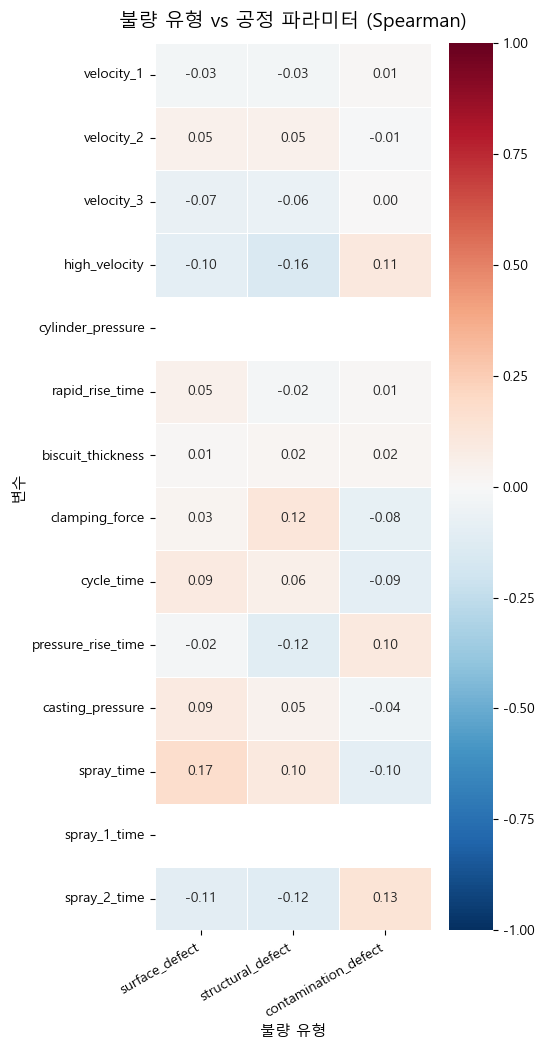

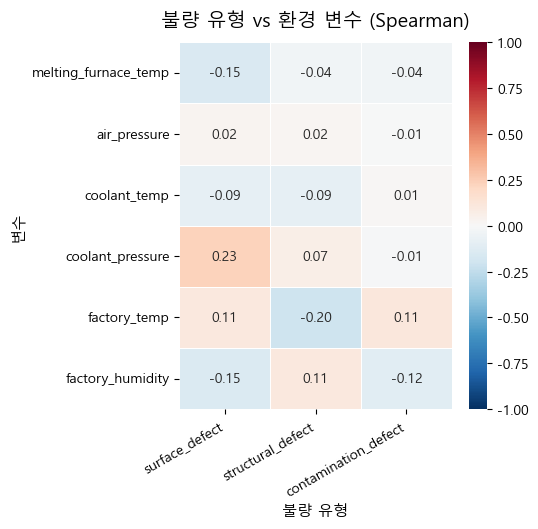

In [49]:
DEFECT_COLS = [
    'surface_defect',
    'structural_defect',
    'contamination_defect'
]

PROCESS_COLS = [
    'velocity_1', 'velocity_2', 'velocity_3', 'high_velocity',
    'cylinder_pressure', 'rapid_rise_time', 'biscuit_thickness',
    'clamping_force', 'cycle_time', 'pressure_rise_time',
    'casting_pressure', 'spray_time', 'spray_1_time', 'spray_2_time',
]

SENSOR_COLS = [
    'melting_furnace_temp', 'air_pressure', 'coolant_temp', 'coolant_pressure',
    'factory_temp', 'factory_humidity'
]

# 함수
def plot_corr_heatmap(df, defect_cols, feature_cols, title):
    corr = df[defect_cols + feature_cols].corr(method='spearman')
    corr_target = corr.loc[feature_cols, defect_cols]

    fig, ax = plt.subplots(
        figsize=(len(defect_cols) * 1.8, len(feature_cols) * 0.65 + 1.5)
    )

    sns.heatmap(
        corr_target,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        ax=ax
    )

    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel('불량 유형', fontsize=11)
    ax.set_ylabel('변수', fontsize=11)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

# 출력
plot_corr_heatmap(df_original_2, DEFECT_COLS, PROCESS_COLS, '불량 유형 vs 공정 파라미터 (Spearman)')
plot_corr_heatmap(df_original_2, DEFECT_COLS, SENSOR_COLS, '불량 유형 vs 환경 변수 (Spearman)')

# 2단계. 정규성 검정
Shapiro-Wilk

QQ plot

In [50]:
# 연속형 변수 정규성 검정 (Shapiro-Wilk)
def create_shapiro_summary(df, df_name, exclude_cols=None, alpha=0.05):
    
    print(f"\n{'='*80}")
    print(f"{df_name} 연속형 변수 정규성 검정 (Shapiro-Wilk)")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    result_list = []
    
    # 각 컬럼별 정규성 검정
    for col in df_copied.columns:
        series = df_copied[col].dropna()
        
        stat, p_value = shapiro(series)
        
        if p_value >= alpha:
            result = "정규성 만족"
        else:
            result = "정규성 불만족"
        
        result_list.append([col, stat, p_value, result])
    
    # 결과표 생성
    shapiro_df = pd.DataFrame(result_list, columns=["변수명", "Shapiro 통계량", "p-value", "판정"])
    shapiro_df = shapiro_df.set_index("변수명")
    
    display(shapiro_df)
    
    return shapiro_df

In [51]:
process_shapiro = create_shapiro_summary(
    df_process_2,
    "process",
    exclude_cols=[
        "velocity_1_outlier_flag", 'velocity_3_outlier_flag','cylinder_pressure_outlier_flag', 
        'rapid_rise_time_outlier_flag','biscuit_thickness_outlier_flag', 'cycle_time_outlier_flag',
        'casting_pressure_outlier_flag', 'spray_time_outlier_flag','spray_1_time_outlier_flag'], 
)
sensor_shapiro = create_shapiro_summary(
    df_sensor_2,
    "sensor",
    exclude_cols = ["factory_temp_outlier_flag"]
)
defects_shapiro = create_shapiro_summary(
    df_defects_2,
    "defects"
)


process 연속형 변수 정규성 검정 (Shapiro-Wilk)



,Shapiro 통계량,p-value,판정
변수명,,,
shot_key,0.798476,1.174811e-53,정규성 불만족
velocity_1,0.926411,1.240283e-37,정규성 불만족
velocity_2,0.969190,3.757826e-26,정규성 불만족
velocity_3,0.985676,7.333695e-18,정규성 불만족
high_velocity,0.648671,9.326014e-64,정규성 불만족
cylinder_pressure,1.000000,1.000000e+00,정규성 만족
rapid_rise_time,0.760207,1.015670e-56,정규성 불만족
biscuit_thickness,0.951757,8.619553e-32,정규성 불만족
clamping_force,0.891286,1.720679e-43,정규성 불만족



sensor 연속형 변수 정규성 검정 (Shapiro-Wilk)



,Shapiro 통계량,p-value,판정
변수명,,,
melting_furnace_temp,0.973086,1.449105e-24,정규성 불만족
air_pressure,0.943995,8.517212e-34,정규성 불만족
coolant_temp,0.971870,4.450284e-25,정규성 불만족
coolant_pressure,0.881055,6.652185e-45,정규성 불만족
factory_temp,0.780887,4.042500e-55,정규성 불만족
factory_humidity,0.863516,4.142469e-47,정규성 불만족



defects 연속형 변수 정규성 검정 (Shapiro-Wilk)



,Shapiro 통계량,p-value,판정
변수명,,,
surface_defect,0.248609,5.050891e-79,정규성 불만족
structural_defect,0.524135,1.196218e-69,정규성 불만족
contamination_defect,0.046663,3.784420e-84,정규성 불만족


In [52]:
# 테이블(데이터프레임)의 컬럼들로 QQ plot 한 번에 출력
def plot_qq_table(df, title=None, exclude_cols=None):
    
    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # 숫자형 컬럼 전체 선택
    cols = df_copied.select_dtypes(include='number').columns.tolist()
    
    fig, axes = plt.subplots(4, 4, figsize=(15, 15))
    axes = axes.flatten()
    
    for i, col in enumerate(cols[:16]):
        series = df_copied[col].dropna()
        
        stats.probplot(series, dist="norm", plot=axes[i])
        axes[i].set_title(col)
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    if title:
        fig.suptitle(title, y=1.02)
    
    plt.tight_layout()
    plt.show()

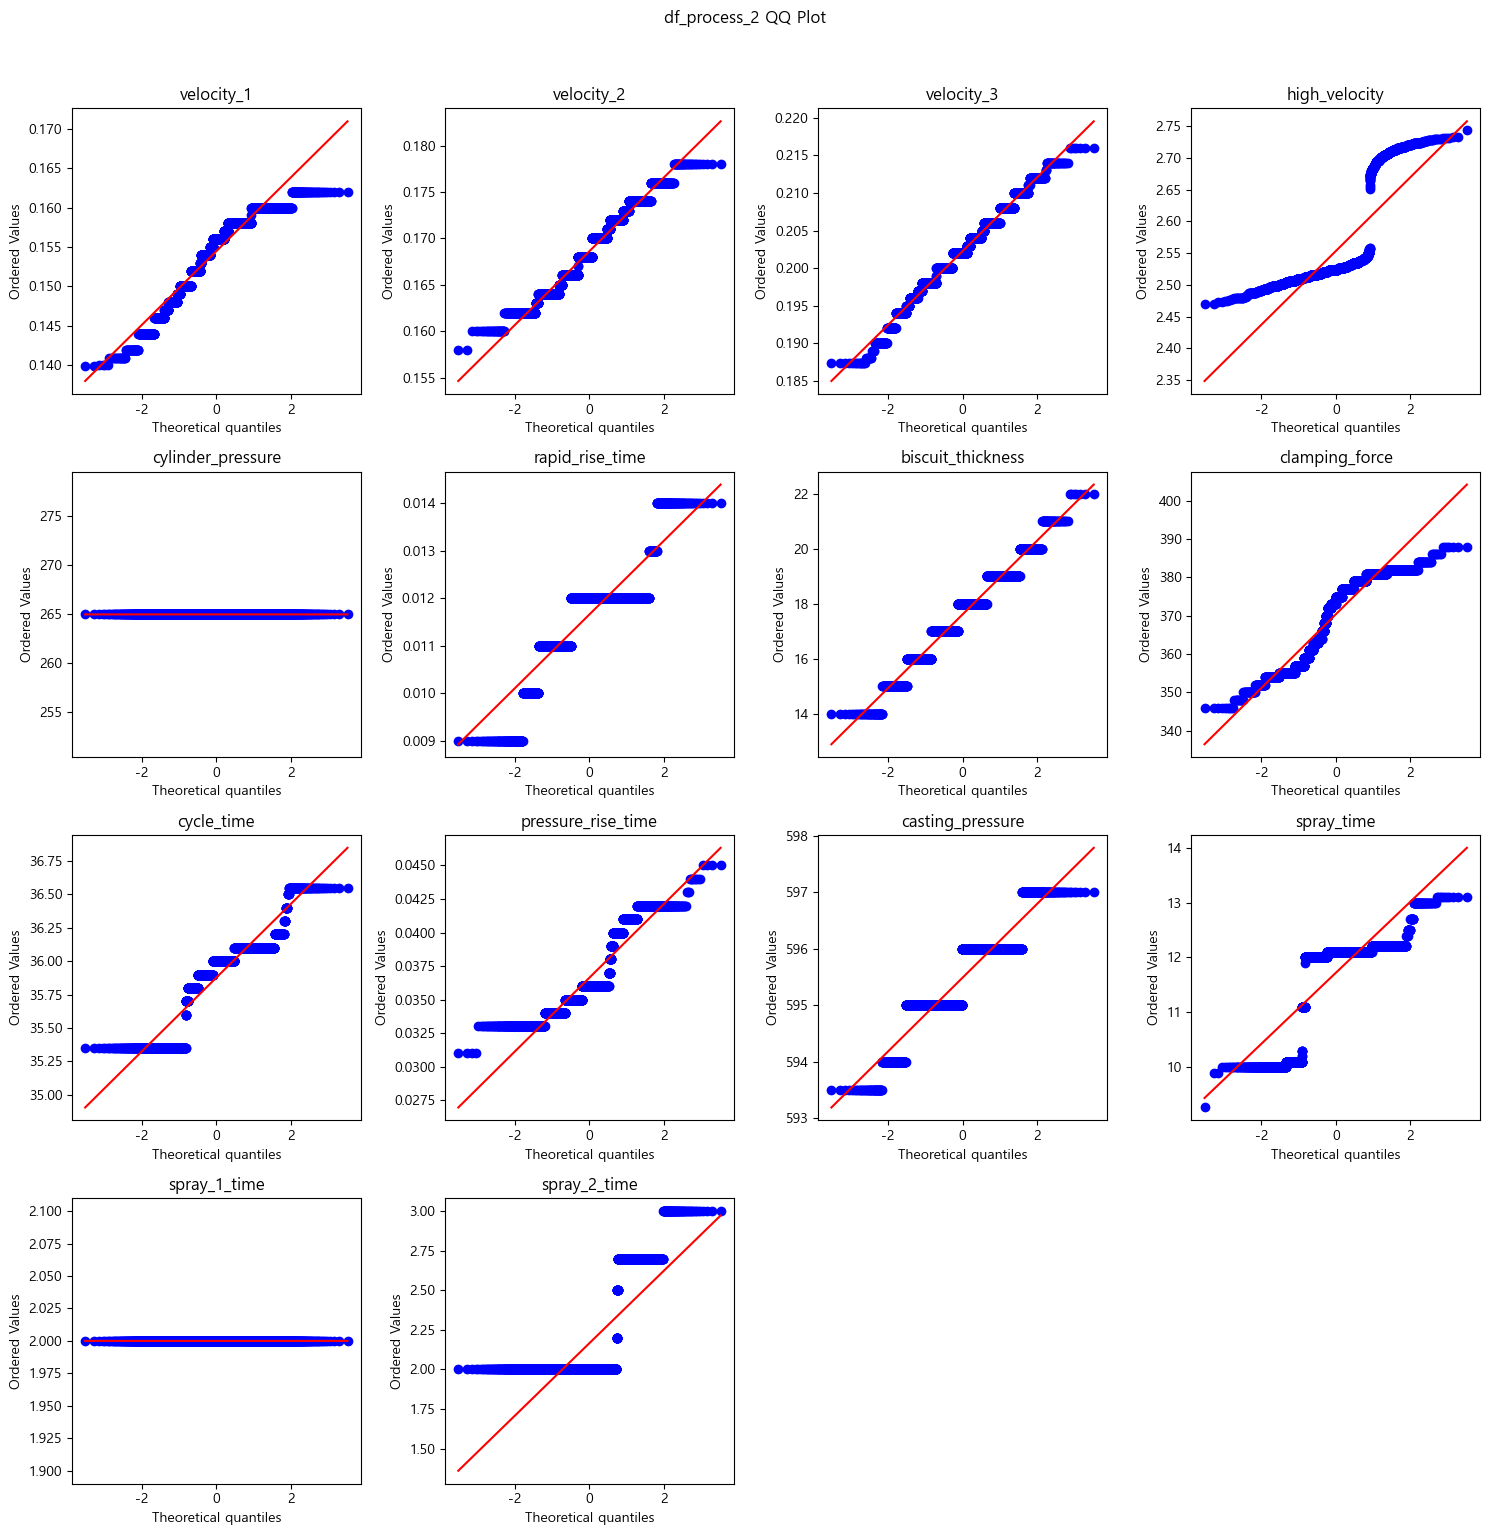

In [53]:
plot_qq_table(df_process_2, 
                title="df_process_2 QQ Plot",
                exclude_cols=[
                    "velocity_1_outlier_flag", 'velocity_3_outlier_flag','cylinder_pressure_outlier_flag', 
                    'rapid_rise_time_outlier_flag','biscuit_thickness_outlier_flag', 'cycle_time_outlier_flag',
                    'casting_pressure_outlier_flag', 'spray_time_outlier_flag','spray_1_time_outlier_flag'], 
    )

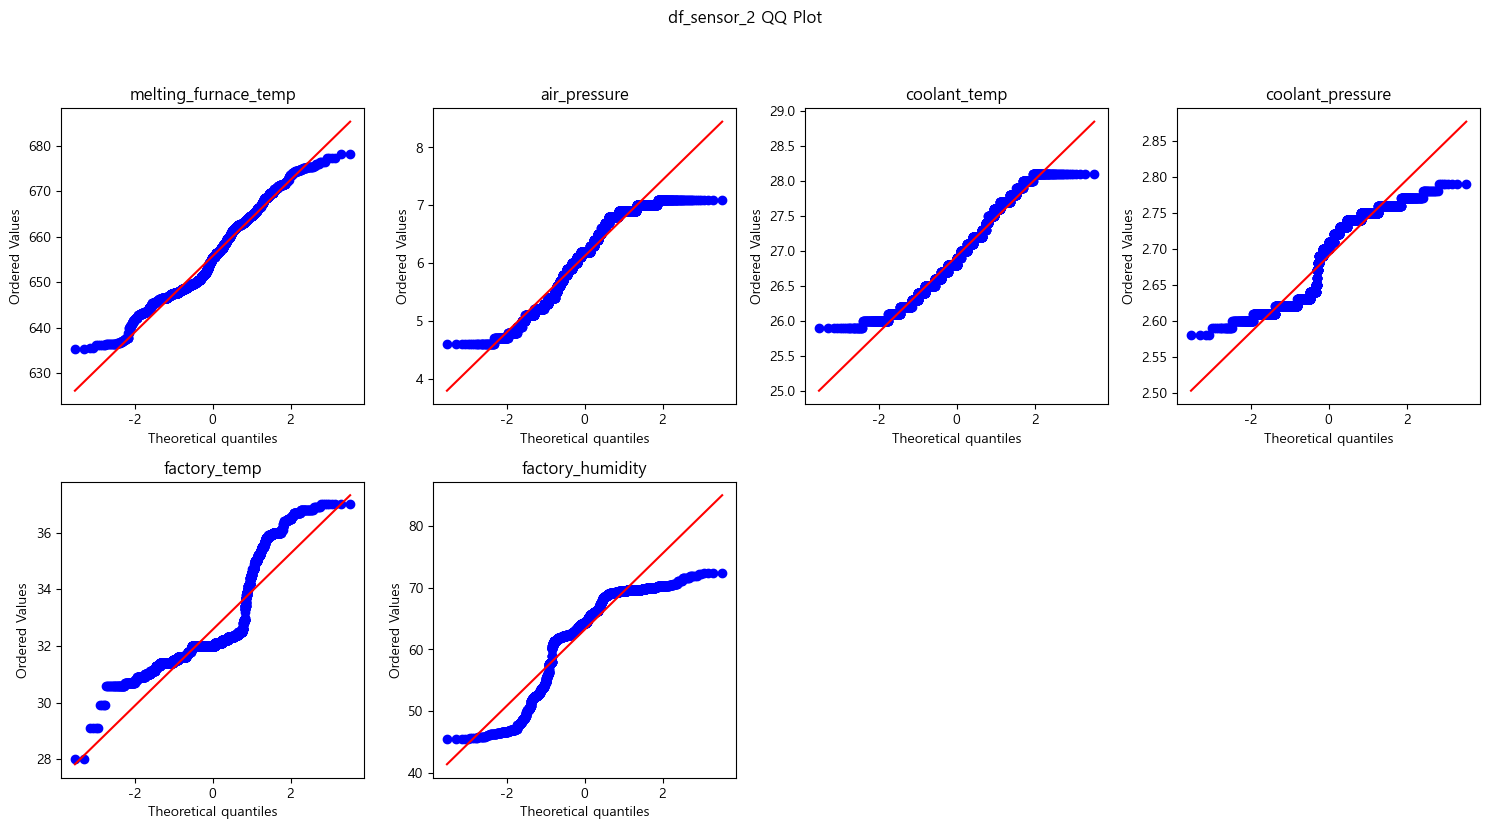

In [54]:
plot_qq_table(df_sensor_2, title="df_sensor_2 QQ Plot", exclude_cols = ["factory_temp_outlier_flag"])

# 3단계. 등분산성 검정

In [55]:
from scipy.stats import levene

def run_levene(df, col, target_col):
    
    group_0 = df[df[target_col] == 0][col].dropna()
    group_1 = df[df[target_col] == 1][col].dropna()
    
    stat, p_value = levene(group_0, group_1)
    print(f"{col} -> Levene 통계량: {stat:.4f}, p-value: {p_value:.4f}")
    
    return stat, p_value

In [56]:
from scipy.stats import levene
import pandas as pd

# 연속형 변수 등분산성 검정 (Levene test)
def create_levene_summary(features_df, defects_df, target_col, df_name, exclude_cols=None, alpha=0.05):
    
    print(f"\n{'='*80}")
    print(f"{df_name} 연속형 변수 등분산성 검정 (Levene test) - 기준: {target_col}")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = features_df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 기준 타깃 시리즈 가져오기
    target_series = defects_df[target_col]
    
    result_list = []
    
    # 각 컬럼별 등분산성 검정
    for col in df_copied.columns:
        group_0 = df_copied[target_series == 0][col].dropna()
        group_1 = df_copied[target_series == 1][col].dropna()
        
        stat, p_value = levene(group_0, group_1)
        
        if p_value >= alpha:
            result = "등분산 만족"
        else:
            result = "등분산 불만족"
        
        result_list.append([col, stat, p_value, result])
    
    # 결과표 생성
    levene_df = pd.DataFrame(
        result_list,
        columns=["변수명", "Levene 통계량", "p-value", "판정"]
    )
    levene_df = levene_df.set_index("변수명")
    
    display(levene_df)
    
    return levene_df

In [57]:
process_levene_surface = create_levene_summary(
    df_process_2,
    df_defects_2,
    "surface_defect",
    "df_process_2",
    exclude_cols=['shot_key',
        'velocity_1_outlier_flag', 'velocity_3_outlier_flag', 'cylinder_pressure_outlier_flag', 
        'rapid_rise_time_outlier_flag', 'biscuit_thickness_outlier_flag', 'cycle_time_outlier_flag',
        'casting_pressure_outlier_flag', 'spray_time_outlier_flag', 'spray_1_time_outlier_flag'
    ]
)
process_levene_surface = create_levene_summary(
    df_process_2,
    df_defects_2,
    "structural_defect",
    "df_process_2",
    exclude_cols=['shot_key',
        'velocity_1_outlier_flag', 'velocity_3_outlier_flag', 'cylinder_pressure_outlier_flag', 
        'rapid_rise_time_outlier_flag', 'biscuit_thickness_outlier_flag', 'cycle_time_outlier_flag',
        'casting_pressure_outlier_flag', 'spray_time_outlier_flag', 'spray_1_time_outlier_flag'
    ]
)
process_levene_surface = create_levene_summary(
    df_process_2,
    df_defects_2,
    "contamination_defect",
    "df_process_2",
    exclude_cols=['shot_key',
        'velocity_1_outlier_flag', 'velocity_3_outlier_flag', 'cylinder_pressure_outlier_flag', 
        'rapid_rise_time_outlier_flag', 'biscuit_thickness_outlier_flag', 'cycle_time_outlier_flag',
        'casting_pressure_outlier_flag', 'spray_time_outlier_flag', 'spray_1_time_outlier_flag'
    ]
)


df_process_2 연속형 변수 등분산성 검정 (Levene test) - 기준: surface_defect



,Levene 통계량,p-value,판정
변수명,,,
velocity_1,0.061166,8.046774e-01,등분산 만족
velocity_2,0.022568,8.805948e-01,등분산 만족
velocity_3,0.851463,3.562058e-01,등분산 만족
high_velocity,25.965999,3.668546e-07,등분산 불만족
cylinder_pressure,NaN,NaN,등분산 불만족
rapid_rise_time,2.032700,1.540408e-01,등분산 만족
biscuit_thickness,0.018153,8.928319e-01,등분산 만족
clamping_force,70.291546,7.455310e-17,등분산 불만족
cycle_time,65.318928,8.827915e-16,등분산 불만족



df_process_2 연속형 변수 등분산성 검정 (Levene test) - 기준: structural_defect



,Levene 통계량,p-value,판정
변수명,,,
velocity_1,6.588676,1.030631e-02,등분산 불만족
velocity_2,1.144535,2.847738e-01,등분산 만족
velocity_3,0.810345,3.680835e-01,등분산 만족
high_velocity,208.203514,7.973080e-46,등분산 불만족
cylinder_pressure,NaN,NaN,등분산 불만족
rapid_rise_time,2.452695,1.174184e-01,등분산 만족
biscuit_thickness,0.582001,4.455832e-01,등분산 만족
clamping_force,144.993082,1.022507e-32,등분산 불만족
cycle_time,45.780487,1.556728e-11,등분산 불만족



df_process_2 연속형 변수 등분산성 검정 (Levene test) - 기준: contamination_defect



,Levene 통계량,p-value,판정
변수명,,,
velocity_1,1.790698,0.180933,등분산 만족
velocity_2,0.532018,0.465811,등분산 만족
velocity_3,0.004376,0.947260,등분산 만족
high_velocity,4.145677,0.041820,등분산 불만족
cylinder_pressure,NaN,NaN,등분산 불만족
rapid_rise_time,0.392733,0.530909,등분산 만족
biscuit_thickness,0.324459,0.568978,등분산 만족
clamping_force,10.904523,0.000969,등분산 불만족
cycle_time,7.729081,0.005464,등분산 불만족


In [58]:
sensor_levene_surface = create_levene_summary(
    df_sensor_2,
    df_defects_2,
    "surface_defect",
    "df_sensor_2"
)

sensor_levene_surface = create_levene_summary(
    df_sensor_2,
    df_defects_2,
    "structural_defect",
    "df_sensor_2"
)

sensor_levene_surface = create_levene_summary(
    df_sensor_2,
    df_defects_2,
    "contamination_defect",
    "df_sensor_2"
)


df_sensor_2 연속형 변수 등분산성 검정 (Levene test) - 기준: surface_defect



,Levene 통계량,p-value,판정
변수명,,,
melting_furnace_temp,65.574167,7.774936e-16,등분산 불만족
air_pressure,75.345291,6.084221e-18,등분산 불만족
coolant_temp,192.865009,1.144082e-42,등분산 불만족
coolant_pressure,355.205736,2.304949e-75,등분산 불만족
factory_temp,50.247877,1.647294e-12,등분산 불만족
factory_humidity,132.681439,3.928359e-30,등분산 불만족
factory_temp_outlier_flag,0.125164,7.235219e-01,등분산 만족



df_sensor_2 연속형 변수 등분산성 검정 (Levene test) - 기준: structural_defect



,Levene 통계량,p-value,판정
변수명,,,
melting_furnace_temp,12.164641,4.933525e-04,등분산 불만족
air_pressure,1.067727,3.015346e-01,등분산 만족
coolant_temp,14.275245,1.606951e-04,등분산 불만족
coolant_pressure,4.739183,2.955317e-02,등분산 불만족
factory_temp,116.471853,1.032387e-26,등분산 불만족
factory_humidity,175.993494,3.533579e-39,등분산 불만족
factory_temp_outlier_flag,6.568215,1.042523e-02,등분산 불만족



df_sensor_2 연속형 변수 등분산성 검정 (Levene test) - 기준: contamination_defect



,Levene 통계량,p-value,판정
변수명,,,
melting_furnace_temp,1.526687,2.166976e-01,등분산 만족
air_pressure,3.738271,5.326421e-02,등분산 만족
coolant_temp,10.270201,1.364746e-03,등분산 불만족
coolant_pressure,40.677985,2.042922e-10,등분산 불만족
factory_temp,4.190950,4.071874e-02,등분산 불만족
factory_humidity,7.819280,5.198870e-03,등분산 불만족
factory_temp_outlier_flag,0.011484,9.146663e-01,등분산 만족


상관관계 분석

# 4단계. 실제 집단 차이 검정


A. 타깃이 0/1 이진 변수
- 정규성 어느 정도 괜찮고 평균 비교 목적이면 → Welch t-test → Cohen's d
- 분포가 많이 찌그러졌거나 이상치 영향이 크면 → Mann-Whitney U → rank-
- 효과 크기

B. 타깃이 3개 이상 다중 범주
- 정규성/등분산성 괜찮으면 → ANOVA → Tukey → 효과크기: eta squared(η²) or omega squared(ω²)
- 등분산성 안 맞으면 → Welch ANOVA → Games-Howell → 효과크기: eta squared(η²) or omega squared(ω²)
- 비모수로 가면 → Kruskal-Wallis → Dunn test (보정 포함) → 효과크기: epsilon squared(ε²)

## A. 타깃이 0/1 이진 변수

### welch-t 검정

In [59]:
from scipy.stats import ttest_ind
# 연속형 변수 실제 집단 차이 검정 (Welch t-test + Cohen's d)
def create_welch_summary(features_df, defects_df, target_col, df_name, exclude_cols=None, alpha=0.05):
    
    print(f"\n{'='*80}")
    print(f"{df_name} 실제 집단 차이 검정 (Welch t-test) - 기준: {target_col}")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외
    df_copied = features_df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')
    
    # 타깃 (index 맞춤)
    target_series = defects_df[target_col].reindex(df_copied.index)
    
    result_list = []
    
    for col in df_copied.columns:
        group_0 = df_copied.loc[target_series == 0, col].dropna()
        group_1 = df_copied.loc[target_series == 1, col].dropna()
        
        # 통계검정: Welch t-검정
        t_stat, p_value = ttest_ind(group_0, group_1, equal_var=False, nan_policy='omit')
        
        # 효과크기: Cohen's d
        # Cohen's d (1그룹 - 0그룹 기준, 양수면 불량=1 그룹 평균이 더 큼)
        mean_0 = group_0.mean()
        mean_1 = group_1.mean()
        std_0 = group_0.std(ddof=1)
        std_1 = group_1.std(ddof=1)
        
        pooled_sd = np.sqrt(((std_0 ** 2) + (std_1 ** 2)) / 2)
        
        if pooled_sd == 0 or np.isnan(pooled_sd):
            cohen_d = np.nan
        else:
            cohen_d = (mean_1 - mean_0) / pooled_sd
        
        if p_value >= alpha:
            result = "유의한 차이 없음 ㅠㅠ"
        else:
            result = "유의한 차이 있음!!!!!"
        
        result_list.append([
            col,
            len(group_0),
            len(group_1),
            mean_0,
            mean_1,
            t_stat,
            p_value,
            cohen_d,
            result
        ])
    
    welch_df = pd.DataFrame(
        result_list,
        columns=[
            "변수명", "0그룹 개수", "1그룹 개수",
            "0그룹 평균", "1그룹 평균",
            "t 통계량", "p-value", "Cohen's d", "판정"
        ]
    ).set_index("변수명")
    
    display(welch_df)
    
    return welch_df

In [60]:
process_exclude_cols = [
    'velocity_1_outlier_flag', 'velocity_3_outlier_flag', 'cylinder_pressure_outlier_flag', 
    'rapid_rise_time_outlier_flag', 'biscuit_thickness_outlier_flag', 'cycle_time_outlier_flag',
    'casting_pressure_outlier_flag', 'spray_time_outlier_flag', 'spray_1_time_outlier_flag'
]

process_welch_surface = create_welch_summary(
    df_process_2,
    df_defects_2,
    "surface_defect",
    "df_process",
    exclude_cols=process_exclude_cols,
    alpha=0.05
)
process_welch_surface = create_welch_summary(
    df_process_2,
    df_defects_2,
    "structural_defect",
    "df_process",
    exclude_cols=process_exclude_cols,
    alpha=0.05
)
process_welch_surface = create_welch_summary(
    df_process_2,
    df_defects_2,
    "contamination_defect",
    "df_process",
    exclude_cols=process_exclude_cols,
    alpha=0.05
)


df_process 실제 집단 차이 검정 (Welch t-test) - 기준: surface_defect



,0그룹 개수,1그룹 개수,0그룹 평균,1그룹 평균,t 통계량,p-value,Cohen's d,판정
변수명,,,,,,,,
velocity_1,3132,196,0.154501,0.154036,1.325357,1.864212e-01,-0.096855,유의한 차이 없음 ㅠㅠ
velocity_2,3132,196,0.168564,0.169515,-3.194985,1.603879e-03,0.236083,유의한 차이 있음!!!!!
velocity_3,3132,196,0.202348,0.200791,4.649358,5.675145e-06,-0.329078,유의한 차이 있음!!!!!
high_velocity,3132,196,2.554923,2.526429,8.940431,5.311591e-17,-0.481776,유의한 차이 있음!!!!!
cylinder_pressure,3132,196,265.000000,265.000000,NaN,NaN,NaN,유의한 차이 있음!!!!!
rapid_rise_time,3132,196,0.011648,0.011867,-3.629522,3.515403e-04,0.257246,유의한 차이 있음!!!!!
biscuit_thickness,3132,196,17.610153,17.612245,-0.021505,9.828624e-01,0.001554,유의한 차이 없음 ㅠㅠ
clamping_force,3132,196,370.190932,372.765306,-4.113472,5.406900e-05,0.275099,유의한 차이 있음!!!!!
cycle_time,3132,196,35.869748,35.991327,-9.520574,6.908780e-19,0.496907,유의한 차이 있음!!!!!



df_process 실제 집단 차이 검정 (Welch t-test) - 기준: structural_defect



,0그룹 개수,1그룹 개수,0그룹 평균,1그룹 평균,t 통계량,p-value,Cohen's d,판정
변수명,,,,,,,,
velocity_1,2550,778,0.154568,0.154163,1.989517,4.686420e-02,-0.082568,유의한 차이 있음!!!!!
velocity_2,2550,778,0.168514,0.168967,-2.735110,6.322372e-03,0.112353,유의한 차이 있음!!!!!
velocity_3,2550,778,0.202439,0.201657,3.928846,8.981080e-05,-0.160047,유의한 차이 있음!!!!!
high_velocity,2550,778,2.562458,2.523050,21.679671,1.473280e-97,-0.672918,유의한 차이 있음!!!!!
cylinder_pressure,2550,778,265.000000,265.000000,NaN,NaN,NaN,유의한 차이 있음!!!!!
rapid_rise_time,2550,778,0.011675,0.011613,1.627489,1.038946e-01,-0.068124,유의한 차이 없음 ㅠㅠ
biscuit_thickness,2550,778,17.601176,17.640103,-0.688227,4.914355e-01,0.028291,유의한 차이 없음 ㅠㅠ
clamping_force,2550,778,369.503529,373.092545,-9.763388,6.687545e-22,0.376736,유의한 차이 있음!!!!!
cycle_time,2550,778,35.867667,35.907198,-3.662100,2.581565e-04,0.139912,유의한 차이 있음!!!!!



df_process 실제 집단 차이 검정 (Welch t-test) - 기준: contamination_defect



,0그룹 개수,1그룹 개수,0그룹 평균,1그룹 평균,t 통계량,p-value,Cohen's d,판정
변수명,,,,,,,,
velocity_1,3309,19,0.154468,0.155421,-1.126143,2.746093e-01,0.221859,유의한 차이 없음 ㅠㅠ
velocity_2,3309,19,0.168623,0.168053,0.703599,4.905523e-01,-0.150811,유의한 차이 없음 ㅠㅠ
velocity_3,3309,19,0.202254,0.202737,-0.415767,6.824425e-01,0.096903,유의한 차이 없음 ㅠㅠ
high_velocity,3309,19,2.552380,2.703895,-44.076826,2.712992e-24,2.954446,유의한 차이 있음!!!!!
cylinder_pressure,3309,19,265.000000,265.000000,NaN,NaN,NaN,유의한 차이 있음!!!!!
rapid_rise_time,3309,19,0.011660,0.011789,-0.497843,6.245805e-01,0.127550,유의한 차이 없음 ㅠㅠ
biscuit_thickness,3309,19,17.608039,18.000000,-1.239596,2.308661e-01,0.285580,유의한 차이 없음 ㅠㅠ
clamping_force,3309,19,370.411605,358.315789,11.463953,5.416329e-10,-1.539592,유의한 차이 있음!!!!!
cycle_time,3309,19,35.879571,35.413158,7.360011,7.245621e-07,-1.623291,유의한 차이 있음!!!!!


In [61]:
process_exclude_cols = ['factory_temp_outlier_flag']


sensor_welch_surface = create_welch_summary(
    df_sensor_2,
    df_defects_2,
    "surface_defect",
    "df_sensor",
    alpha=0.05
)
sensor_welch_surface = create_welch_summary(
    df_sensor_2,
    df_defects_2,
    "structural_defect",
    "df_sensor",
    alpha=0.05
)
sensor_welch_surface = create_welch_summary(
    df_sensor_2,
    df_defects_2,
    "contamination_defect",
    "df_sensor",
    alpha=0.05
)


df_sensor 실제 집단 차이 검정 (Welch t-test) - 기준: surface_defect



,0그룹 개수,1그룹 개수,0그룹 평균,1그룹 평균,t 통계량,p-value,Cohen's d,판정
변수명,,,,,,,,
melting_furnace_temp,3132,196,656.017114,650.700510,10.923136,8.454413e-23,-0.703276,유의한 차이 있음!!!!!
air_pressure,3132,196,6.113027,6.241327,-3.982873,8.784878e-05,0.225179,유의한 차이 있음!!!!!
coolant_temp,3132,196,26.936526,26.712755,12.242019,1.868335e-29,-0.525305,유의한 차이 있음!!!!!
coolant_pressure,3132,196,2.686494,2.741633,-35.071254,7.647272e-142,1.324799,유의한 차이 있음!!!!!
factory_temp,3132,196,32.584517,32.373469,3.498679,5.353129e-04,-0.172758,유의한 차이 있음!!!!!
factory_humidity,3132,196,63.263697,62.025510,5.212458,3.172380e-07,-0.237610,유의한 차이 있음!!!!!
factory_temp_outlier_flag,3132,196,0.000639,0.000000,1.414439,1.573323e-01,-0.035743,유의한 차이 없음 ㅠㅠ



df_sensor 실제 집단 차이 검정 (Welch t-test) - 기준: structural_defect



,0그룹 개수,1그룹 개수,0그룹 평균,1그룹 평균,t 통계량,p-value,Cohen's d,판정
변수명,,,,,,,,
melting_furnace_temp,2550,778,655.854039,655.212211,1.915319,5.566040e-02,-0.076977,유의한 차이 없음 ㅠㅠ
air_pressure,2550,778,6.112196,6.148072,-1.293262,1.961524e-01,0.052972,유의한 차이 없음 ㅠㅠ
coolant_temp,2550,778,26.949647,26.837147,4.761466,2.156420e-06,-0.199708,유의한 차이 있음!!!!!
coolant_pressure,2550,778,2.688122,2.695051,-2.893423,3.878602e-03,0.120735,유의한 차이 있음!!!!!
factory_temp,2550,778,32.762118,31.949238,17.708825,6.644375e-66,-0.618565,유의한 차이 있음!!!!!
factory_humidity,2550,778,62.557216,65.267352,-13.626753,8.619911e-41,0.470872,유의한 차이 있음!!!!!
factory_temp_outlier_flag,2550,778,0.000000,0.002571,-1.415124,1.574326e-01,0.071750,유의한 차이 없음 ㅠㅠ



df_sensor 실제 집단 차이 검정 (Welch t-test) - 기준: contamination_defect



,0그룹 개수,1그룹 개수,0그룹 평균,1그룹 평균,t 통계량,p-value,Cohen's d,판정
변수명,,,,,,,,
melting_furnace_temp,3309,19,655.725446,651.968421,1.864063,7.853109e-02,-0.435510,유의한 차이 없음 ㅠㅠ
air_pressure,3309,19,6.120762,6.089474,0.262318,7.959972e-01,-0.051875,유의한 차이 없음 ㅠㅠ
coolant_temp,3309,19,26.923058,26.973684,-0.681303,5.040675e-01,0.112036,유의한 차이 없음 ㅠㅠ
coolant_pressure,3309,19,2.689698,2.697368,-2.548387,1.811960e-02,0.187484,유의한 차이 있음!!!!!
factory_temp,3309,19,32.553039,35.889474,-26.377092,8.318704e-17,2.951895,유의한 차이 있음!!!!!
factory_humidity,3309,19,63.273738,48.742105,19.832692,4.120622e-14,-2.824769,유의한 차이 있음!!!!!
factory_temp_outlier_flag,3309,19,0.000604,0.000000,1.414427,1.573306e-01,-0.034773,유의한 차이 없음 ㅠㅠ
